## NYC Taxi — Isolation Forest Baseline

Anomaly detection on the NAB `realKnownCause/nyc_taxi.csv` series using an Isolation Forest (IF) model. This series records half-hourly NYC taxi trip counts and contains five labeled anomaly windows corresponding to known external events (e.g., NYC Marathon, Thanksgiving, Christmas, New Year's, a January blizzard).

In [14]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

### Configuration

Set dataset path, feature engineering parameters, and random seed. All downstream cells read from these constants — change them here to run on a different series.

In [15]:
# --- Config ---
NAB_ROOT = Path("../NAB")  # change if needed
nab_rel_path = "realKnownCause/nyc_taxi.csv"

SEASONAL_PERIOD = 48       # hourly data → daily seasonality
ROLL_WINDOW = 24
TRAIN_FRAC = 0.7

RANDOM_STATE = 42

### Load Data and Labels

Load the CSV and attach NAB point labels. Labels are stored in `combined_labels.json` as a mapping from series path to a list of anomaly timestamps. We parse them as `datetime64` and join to the DataFrame to avoid string-format mismatches.

In [16]:
DATA_ROOT = NAB_ROOT / "data"
LABELS_PATH = NAB_ROOT / "labels" / "combined_labels.json"

with open(LABELS_PATH, "r") as f:
    combined_labels = json.load(f)

csv_path = DATA_ROOT / nab_rel_path
df = pd.read_csv(csv_path, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

# Labels: parse as timestamps (avoid string-format mismatch)
label_ts = pd.to_datetime(combined_labels.get(nab_rel_path, []))
df["is_anomaly"] = df["timestamp"].isin(label_ts).astype(int)

df.head(), df["is_anomaly"].sum()


(            timestamp  value  is_anomaly
 0 2014-07-01 00:00:00  10844           0
 1 2014-07-01 00:30:00   8127           0
 2 2014-07-01 01:00:00   6210           0
 3 2014-07-01 01:30:00   4656           0
 4 2014-07-01 02:00:00   3820           0,
 np.int64(5))

### Train / Test Split

Split chronologically: the first 70% of timesteps form the training set (used to fit the model and derive thresholds), the remaining 30% the test set (used for evaluation only). All 5 labeled anomalies fall in the test window.

In [17]:
def time_split(df: pd.DataFrame, train_frac: float = 0.7):
    split_idx = int(len(df) * train_frac)
    return df.iloc[:split_idx].copy(), df.iloc[split_idx:].copy()

train_df, test_df = time_split(df, TRAIN_FRAC)

(train_df.shape, test_df.shape, train_df["is_anomaly"].sum(), test_df["is_anomaly"].sum())

((7223, 3), (3097, 3), np.int64(2), np.int64(3))

### Feature Engineering

Build a feature matrix from the raw `value` series:

| Feature | Description |
|---|---|
| `seasonal_diff` | $x_t - x_{t-24}$ — removes daily seasonality |
| `lag1` | Previous step's seasonal diff |
| `lag24` | One day ago's seasonal diff |
| `rolling_mean_24` | 24-step rolling mean of seasonal diff |
| `rolling_std_24` | 24-step rolling std of seasonal diff |

These features capture both local deviation and short-term context, which Isolation Forest uses to detect structurally unusual points.

In [18]:
def make_features(df: pd.DataFrame, value_col="value", seasonal_period=24, roll_window=24):
    out = df.copy()

    # seasonal differencing
    out["seasonal_diff"] = out[value_col] - out[value_col].shift(seasonal_period)

    # lags
    out["lag1"] = out["seasonal_diff"].shift(1)
    out["lag24"] = out["seasonal_diff"].shift(seasonal_period)

    # rolling context
    out["rolling_mean_24"] = out["seasonal_diff"].rolling(roll_window, min_periods=roll_window//2).mean()
    out["rolling_std_24"]  = out["seasonal_diff"].rolling(roll_window, min_periods=roll_window//2).std(ddof=0)

    feature_cols = ["seasonal_diff", "lag1", "lag24", "rolling_mean_24", "rolling_std_24"]
    return out, feature_cols

feat_df, feature_cols = make_features(df, "value", SEASONAL_PERIOD, ROLL_WINDOW)
feat_df[["timestamp", "value", "is_anomaly"] + feature_cols].tail(10)

,timestamp,value,is_anomaly,seasonal_diff,lag1,lag24,rolling_mean_24,rolling_std_24
10310,2015-01-31 19:00:00,28804,0,1515.0,1528.0,3825.0,1432.833333,5549.126520
10311,2015-01-31 19:30:00,27773,0,-334.0,1515.0,4764.0,1940.791667,4748.400573
10312,2015-01-31 20:00:00,24985,0,-2323.0,-334.0,4111.0,2366.291667,3793.753424
10313,2015-01-31 20:30:00,23291,0,-3279.0,-2323.0,3450.0,2603.000000,3212.354121
10314,2015-01-31 21:00:00,23719,0,-2216.0,-3279.0,2727.0,2768.375000,2835.773701
10315,2015-01-31 21:30:00,24670,0,-1762.0,-2216.0,3244.0,2708.750000,2914.271982
10316,2015-01-31 22:00:00,25721,0,-1018.0,-1762.0,4101.0,2643.458333,2978.767796
10317,2015-01-31 22:30:00,27309,0,435.0,-1018.0,5373.0,2515.958333,3004.963928
10318,2015-01-31 23:00:00,26591,0,-337.0,435.0,6209.0,2344.666667,3045.269004
10319,2015-01-31 23:30:00,26288,0,288.0,-337.0,8123.0,2125.208333,2995.383044


### Prepare Feature Arrays

Align features with the train/test split and drop rows with NaN (caused by lag and rolling operations at the start of the series). Extract numpy arrays for the model.

In [19]:
train_feat = feat_df.loc[train_df.index].dropna(subset=feature_cols).copy()
test_feat  = feat_df.loc[test_df.index].dropna(subset=feature_cols).copy()

X_train = train_feat[feature_cols].values
X_test  = test_feat[feature_cols].values
y_test  = test_feat["is_anomaly"].astype(int).values

X_train.shape, X_test.shape, y_test.sum()

((7127, 5), (3097, 5), np.int64(3))

### Fit Isolation Forest

Train an Isolation Forest on the training features. `contamination=0.02` provides a rough prior for tree splitting but final alert thresholds are set separately via the alert budget sweep below — so this value has limited impact on evaluation.

The raw `decision_function` is negated so that **higher score = more anomalous**, consistent with the MAD baseline convention.

In [20]:
iforest = IsolationForest(
    n_estimators=300,
    contamination=0.02,     # rough prior; final alerting controlled by thresholding
    random_state=RANDOM_STATE,
    n_jobs=-1
)

iforest.fit(X_train)

# Invert decision_function so higher = more anomalous
train_feat["if_score"] = -iforest.decision_function(X_train)
test_feat["if_score"]  = -iforest.decision_function(X_test)

test_feat[["timestamp", "value", "is_anomaly", "if_score"]].head()

,timestamp,value,is_anomaly,if_score
7223,2014-11-28 11:30:00,15281,0,-0.196267
7224,2014-11-28 12:00:00,16153,0,-0.187780
7225,2014-11-28 12:30:00,17025,0,-0.190960
7226,2014-11-28 13:00:00,17596,0,-0.179866
7227,2014-11-28 13:30:00,18437,0,-0.172968


### Anomaly Score Ranking

Rank all test points by their IF score (rank 1 = most anomalous) and inspect where the five labeled anomalies fall. If the model is discriminative, labeled anomalies should cluster near the top of the ranking.

In [21]:
test_feat["rank"] = test_feat["if_score"].rank(ascending=False)
test_feat.loc[test_feat["is_anomaly"] == 1, ["timestamp", "if_score", "rank"]]

,timestamp,if_score,rank
8526,2014-12-25 15:00:00,-0.106550,606.0
8834,2015-01-01 01:00:00,0.007099,118.0
10080,2015-01-27 00:00:00,0.038705,34.0


### Alert Budget Sweep

Evaluate the IF model at multiple alert budgets (0.5%, 1%, 2%, 5% of test steps). For each budget, the threshold is set to the corresponding percentile of the **training** score distribution — no test labels used. Metrics reported:

- **precision / recall / F1** — point-level against NAB labels
- **AP** — average precision (area under precision-recall curve)
- **alert_rate_actual** — fraction of test steps that fire

In [22]:
def eval_at_alert_budget(train_scores, test_scores, y_true, alert_rate):
    p = 100 * (1 - alert_rate)                # e.g., 99 for 1% alert budget
    t = np.percentile(train_scores, p)        # threshold derived from TRAIN only

    y_pred = (test_scores > t).astype(int)

    return {
        "alert_rate_target": alert_rate,
        "threshold_percentile": p,
        "threshold": float(t),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "alerts": int(y_pred.sum()),
        "alert_rate_actual": float(y_pred.mean()),
        "ap": float(average_precision_score(y_true, test_scores)) if y_true.sum() > 0 else np.nan,
    }, y_pred

train_scores = train_feat["if_score"].values
test_scores  = test_feat["if_score"].values

budgets = [0.005, 0.01, 0.02, 0.05]  # 0.5%, 1%, 2%, 5%

rows = []
preds = {}

for b in budgets:
    row, y_pred = eval_at_alert_budget(train_scores, test_scores, y_test, b)
    rows.append(row)
    preds[b] = y_pred

results_if = pd.DataFrame(rows).sort_values("f1", ascending=False)
results_if

,alert_rate_target,threshold_percentile,threshold,precision,recall,f1,alerts,alert_rate_actual,ap
0,0.005,99.5,3.386887e-02,0.022222,0.333333,0.041667,45,0.014530,0.017104
2,0.020,98.0,-4.295473e-17,0.014184,0.666667,0.027778,141,0.045528,0.017104
1,0.010,99.0,1.912839e-02,0.012500,0.333333,0.024096,80,0.025831,0.017104
3,0.050,95.0,-4.027464e-02,0.007018,0.666667,0.013889,285,0.092025,0.017104


### Near-Hit Evaluation

Exact timestamp matching is too strict for operational use. `near_hit_evaluation` relaxes matching to a configurable time tolerance (default: ±60 min):

- A labeled anomaly is **hit** if any prediction falls within the tolerance window around it.
- Reports recall over anomaly events, matched predictions, and total alerts.

Run at each alert budget to see how detection rate changes as the alert budget tightens.

In [23]:
def near_hit_evaluation(
    df,
    pred_col,
    ts_col="timestamp",
    label_col="is_anomaly",
    tolerance="60min",
):
    """
    Computes near-hit recall within a specified time tolerance.

    Returns:
        recall (float)
        matched_true (int)
        total_true (int)
        matched_predictions (int)
        total_predictions (int)
    """
    tol = pd.Timedelta(tolerance)

    true_ts = df.loc[df[label_col] == 1, ts_col].sort_values()
    pred_ts = df.loc[df[pred_col] == 1, ts_col].sort_values()

    total_true = len(true_ts)
    total_pred = len(pred_ts)

    if total_true == 0:
        return 0.0, 0, 0, 0, total_pred

    matched_true = 0
    matched_pred_indices = set()

    for i, t in enumerate(true_ts):
        # Find predictions within tolerance
        mask = (pred_ts >= t - tol) & (pred_ts <= t + tol)
        if mask.any():
            matched_true += 1
            # Track which prediction(s) were used
            matched_pred_indices.update(pred_ts[mask].index.tolist())

    recall = matched_true / total_true
    matched_predictions = len(matched_pred_indices)

    return recall, matched_true, total_true, matched_predictions, total_pred

In [24]:
for b in budgets:
    tmp = test_feat.copy()
    tmp["pred"] = preds[b]
    result = near_hit_evaluation(tmp, pred_col="pred", tolerance="60min")
    print(f"alert_budget={int(b*100)}%  near-hit recall={result[0]:.3f}  matched={result[1]}/{result[2]}  pred_alerts={result[4]}")

alert_budget=0%  near-hit recall=0.333  matched=1/3  pred_alerts=45
alert_budget=1%  near-hit recall=0.667  matched=2/3  pred_alerts=80
alert_budget=2%  near-hit recall=0.667  matched=2/3  pred_alerts=141
alert_budget=5%  near-hit recall=0.667  matched=2/3  pred_alerts=285


### Score Distribution

Plot the distribution of IF scores on the test set. The vertical red line marks the mean score of labeled anomaly points. If the model is working well, labeled anomalies should sit in the right tail of the distribution, well separated from normal points.

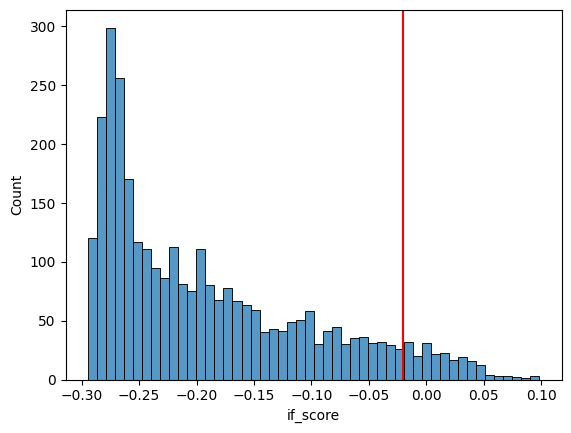

In [25]:
import seaborn as sns

sns.histplot(test_feat["if_score"], bins=50)
plt.axvline(test_feat.loc[test_feat["is_anomaly"] == 1, "if_score"].mean(), color="red")
plt.show()

### Percentile Rank of Labeled Anomalies

Show what percentile each labeled anomaly's IF score falls at relative to the full test set. A value of 0.95 means the score is higher than 95% of all test points. Values close to 1.0 indicate the model ranks that anomaly near the top.

In [26]:
test_feat.loc[test_feat["is_anomaly"] == 1, "if_score"].rank(pct=True)

8526     0.333333
8834     0.666667
10080    1.000000
Name: if_score, dtype: float64